# Analysis Primitives
Welcome to the Analysis Primitives tutorial! While our previous notebooks focused on biomechanics and spatial geometry, this notebook focuses on **Statistics, and Signal Processing**.

Analysis Primitives are domain-agnostic mathematical tools. You can feed them 3D trajectories, 1D speeds, or even the output of other features!

In this tutorial, we will evaluate the speeds of the subject's hands to answer three questions:

1. **Rarity**: Is the current speed anomalous compared to the last few seconds?

2. **Statistical Moments**: What is the rolling average and volatility (standard deviation) of the movement?

3. **Synchronization**: Are the left and right hands phase-locked (moving together)?

## Loading the Data
We will load our standard tensor data. Because we are analyzing the speeds of both hands to check their synchronization, we will extract the indices for both the right and left hand markers.

In [1]:
import numpy as np
from utils.data_loader import load_qualisys_tsv
from utils.plot_utils import plot_feature_timeseries

# Load the data
pos_tensor, vel_tensor, _, marker_names = load_qualisys_tsv("data/trial0001_impulsive.tsv")

right_hand_idx = marker_names.index("HAND_RIGHT")
left_hand_idx = marker_names.index("HAND_LEFT")

N_frames = pos_tensor.shape[0]
print(f"Loaded {N_frames} frames. Ready to analyze bimanual coordination!")

Loaded 7289 frames. Ready to analyze bimanual coordination!


## Setting up the Primitives
We will set up specific `SlidingWindow` instances for our primitives:
- **Rarity & Statistics**: These evaluate a single signal (the right hand's speed), so they need a 1D window (`n_signals=1`).
- Synchronization: This evaluates the Phase Locking Value (PLV) between *two* signals to see if they are oscillating together. It requires a window with two signals (`n_signals=2`).

*Mathematical Note: Rarity uses a rolling probability distribution. It calculates the histogram of the sliding window and compares the probability of the current frame to the probability of the most common bin.*
$$Rarity = \alpha \times \Delta_{Bins} \times \Delta_{Probability}$$

In [3]:
from pyeyesweb.data_models.sliding_window import SlidingWindow
from pyeyesweb.analysis_primitives.rarity import Rarity
from pyeyesweb.analysis_primitives.statistical_moment import StatisticalMoment
from pyeyesweb.analysis_primitives.synchronization import Synchronization

# 1. Initialize Windows
# Single signal windows (Right Hand Speed)
sw_single_speed = SlidingWindow(max_length=100, n_signals=1, n_dims=1)
# Dual signal window (Right and Left Hand Speeds)
sw_dual_speed = SlidingWindow(max_length=100, n_signals=2, n_dims=1)

# 2. Initialize Features
rarity_feature = Rarity(alpha=0.5)
# Explicitly request just the mean and standard deviation
stats_feature = StatisticalMoment(methods=["mean", "std_dev"])
# Evaluate Phase Locking Value without pre-filtering for this example
sync_feature = Synchronization(filter_params=None)

## The Execution Loop
As we loop through the velocity tensor, we will extract the 1D speeds for both hands. Notice how we format the data when pushing it into the dual-signal window: `[[right_speed], [left_speed]]`.

Processing Primitives: 100%|██████████| 7289/7289 [00:04<00:00, 1522.08it/s]


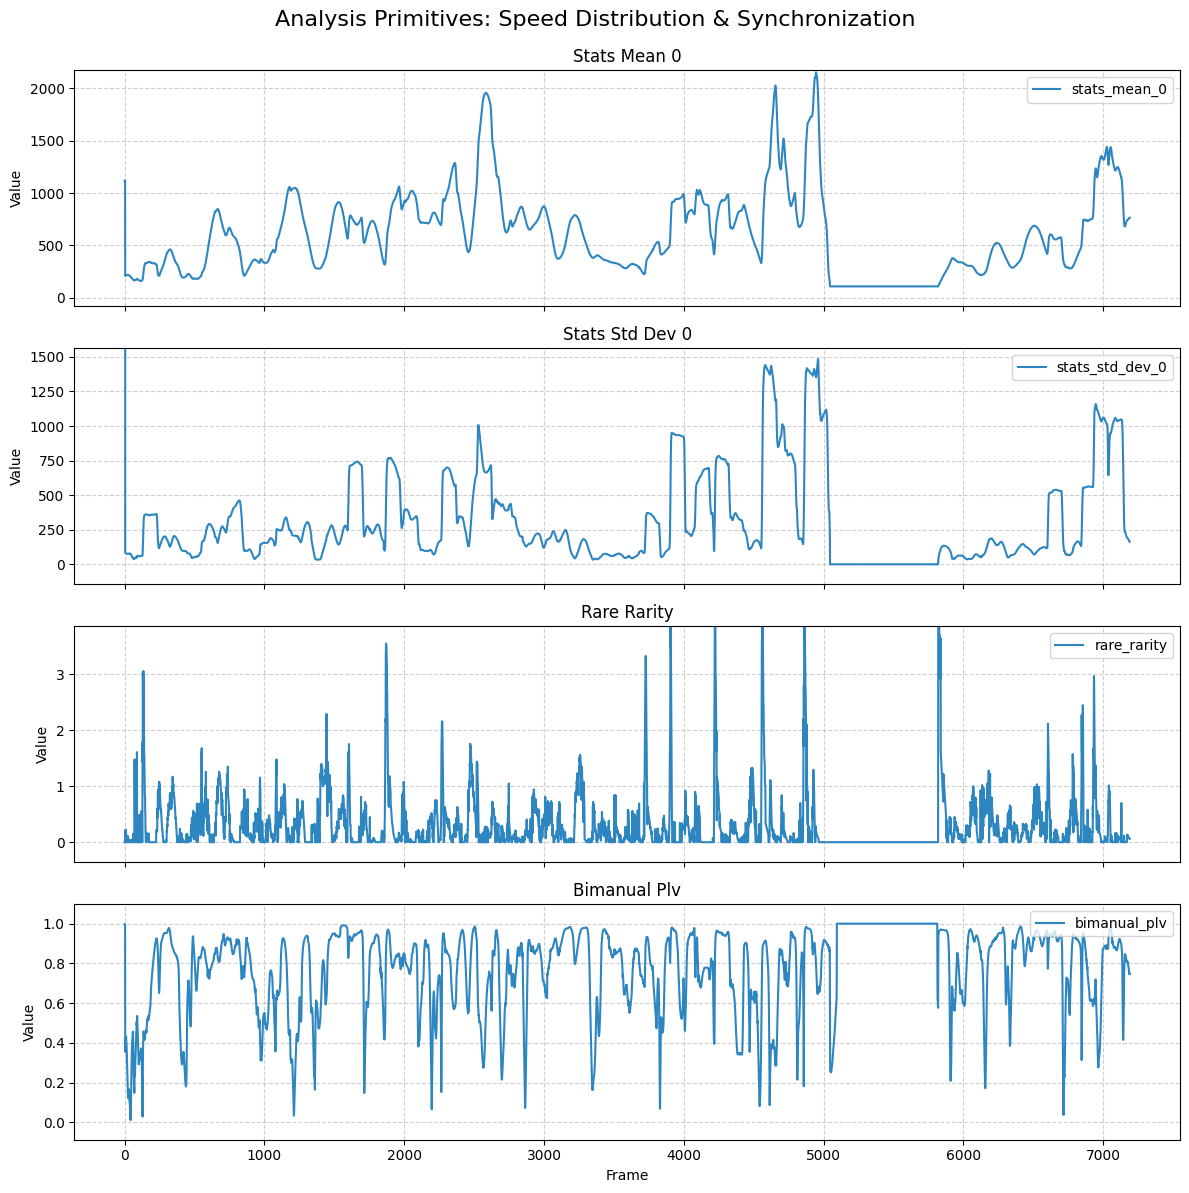

In [5]:
from tqdm.auto import tqdm

results = []

for vel_frame in tqdm(vel_tensor, desc="Processing Primitives"):

    # 1. Extract the scalar speeds for both hands
    right_speed = np.linalg.norm(vel_frame[right_hand_idx])
    left_speed = np.linalg.norm(vel_frame[left_hand_idx])

    # 2. Push to windows
    sw_single_speed.append([[right_speed]])
    # Note the shape for n_signals=2!
    sw_dual_speed.append([[right_speed], [left_speed]])

    # 3. Wait for the window to fill
    if len(sw_single_speed) < sw_single_speed.max_length:
        continue

    # 4. Compute and flatten
    res_rare = rarity_feature(sw_single_speed).to_flat_dict("rare")
    res_stats = stats_feature(sw_single_speed).to_flat_dict("stats")
    res_sync = sync_feature(sw_dual_speed).to_flat_dict("bimanual")

    # 5. Merge and store (Python 3.9+ syntax)
    results.append(res_rare | res_stats | res_sync)

# 6. Visualize the specific metrics
desired_metrics = [
    "stats_mean_0",        # Rolling average speed of the right hand
    "stats_std_dev_0",     # Rolling volatility of the right hand
    "rare_rarity",         # Is the current right hand speed anomalous?
    "bimanual_plv"         # Are the two hands moving in sync? (0 to 1)
]

plot_feature_timeseries(
    results_list=results,
    metrics_to_plot=desired_metrics,
    title="Analysis Primitives: Speed Distribution & Synchronization"
)

**Interpreting the Plot**

These primitives give us a profound, high-level understanding of the movement's texture:

- `stats_mean` & `stats_std_dev`: These show us the "envelope" of the movement. A high standard deviation means the movement is highly erratic or oscillating wildly.

- `rare_rarity`: When this spikes, the subject has performed an action that heavily breaks their established pattern from the last few seconds (like a sudden, unexpected stop or a lightning-fast strike).

- `bimanual_plv`: The Phase Locking Value ranges from 0 to 1. If it stays close to 1.0, the left and right hands are perfectly coupled (e.g., clapping, or holding a box). If it drops, the hands are performing independent, decoupled tasks!